# Procesamiento de Datos - Espectroscopía de Reflectancia

### 1. Marco Teórico y Contexto del Equipo

Para la redacción del reporte técnico, ten en cuenta los siguientes detalles del equipo que usamos:
* **Espectrómetro:** Usamos el sensor en chip **Hamamatsu C12880MA**. Según la hoja de datos, cuenta con un sensor de imagen lineal CMOS de **288 píxeles**. Es por eso que nuestros archivos `.txt` tienen exactamente 288 datos de intensidad.
* **Fuentes de Luz:** Empleamos una **lámpara halógena de deuterio** para las mediciones porque emite un espectro continuo en un rango muy amplio (nos sirve para barrer todo el visible). Para la calibración de las longitudes de onda, la guía estipula el uso de lámparas de **Mercurio-Argón (Hg-Ar)**, ya que estas emiten picos discretos en posiciones atómicas conocidas (ej. 435.84 nm para Hg).

En esta primera celda vamos a cargar los datos puros (intensidades en unidades arbitrarias) y darles una limpieza básica porque los `.txt` venían con corchetes y saltos de línea raros.

Dimensiones de los datos: Ruido (288), Referencia (288), Película (288)


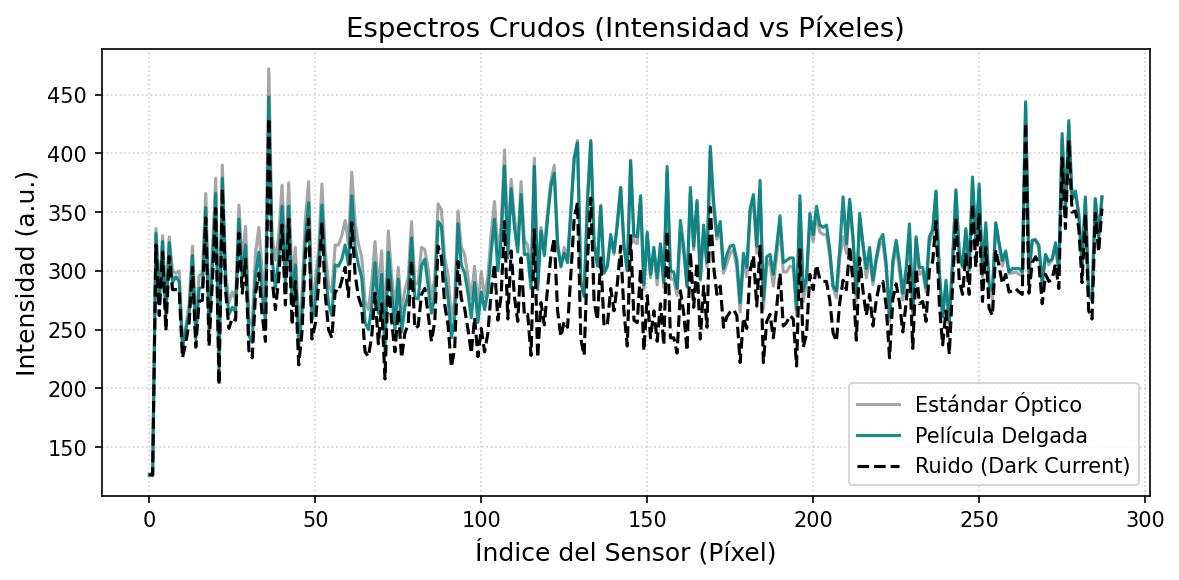

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

def cargar_espectro(ruta_archivo):
    """
    Lee los archivos .txt del espectrómetro, elimina los corchetes y la palabra
    'source:', y devuelve un arreglo unidimensional de NumPy con las intensidades.
    """
    with open(ruta_archivo, 'r') as f:
        texto = f.read()

    # Limpiamos basura del archivo de texto original
    texto_limpio = texto.replace('[', '').replace(']', '').replace('\n', ' ')

    # Extraemos solo los valores numéricos
    datos = []
    for valor in texto_limpio.split():
        if valor.replace('.','',1).isdigit() or valor.isdigit():
            datos.append(float(valor))

    return np.array(datos)

# Cargamos los tres archivos del laboratorio
# IMPORTANTE: Asegúrate de subir estos tres archivos a los archivos temporales de Colab
ruido = cargar_espectro('espectro_ruido.txt')
referencia = cargar_espectro('espectro_estandar_ocean_optics.txt')
pelicula = cargar_espectro('espectro_pelicula_sofia.txt')

print(f"Dimensiones de los datos: Ruido ({len(ruido)}), Referencia ({len(referencia)}), Película ({len(pelicula)})")

# Gráfica exploratoria 1: Datos crudos por píxel
plt.figure(figsize=(8, 4))
plt.plot(referencia, label='Estándar Óptico', color='gray', alpha=0.7)
plt.plot(pelicula, label='Película Delgada', color='teal', alpha=0.9)
plt.plot(ruido, label='Ruido (Dark Current)', color='black', linestyle='--')
plt.title('Espectros Crudos (Intensidad vs Píxeles)')
plt.xlabel('Índice del Sensor (Píxel)')
plt.ylabel('Intensidad (a.u.)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### ¿Por qué los tres espectros crudos se ven casi iguales?

Si graficamos los datos puros sin procesar, notarás que las curvas de Ruido, Referencia y Película tienen casi la misma forma y los mismos picos extraños. ¿Por qué ocurre esto si son cosas totalmente distintas?

1. **La Corriente de Oscuridad (Dark Current):** Los sensores CMOS pequeños (como nuestro Hamamatsu) son muy sensibles a la temperatura. Incluso tapando completamente la entrada de luz, los electrones térmicos saltan en los píxeles generando una señal de "ruido" muy alta (entre 250 y 400 unidades de intensidad).
2. **La firma del detector:** Esos picos falsos que se repiten en el píxel ~35 o ~115 no son colores de la lámpara ni de la muestra; son variaciones de ganancia de cada píxel del propio chip físico.
3. **El verdadero efecto óptico:** La información real de la película de Sofía está "escondida" en diferencias muy sutiles de intensidad (apenas unos pocos niveles de gris por encima del ruido). Por eso, si no restamos el ruido de fondo, es imposible ver la física del experimento.

### 2. Calibración y Espectro de Reflectancia

El eje X anterior estaba en "píxeles". Para pasarlo a nanómetros (nm), usamos el rango de calibración. El software del laboratorio mapeó los 288 píxeles del sensor Hamamatsu en un rango aproximado de 320 nm a 1000 nm.

Una vez calibrado el eje, calculamos la reflectancia especular $R(\lambda)$. La ecuación teórica para normalizar la luz que refleja nuestra muestra es:

$$R(\lambda) = \frac{I_r(\lambda) - I_{noise}(\lambda)}{I_o(\lambda) - I_{noise}(\lambda)}$$

Donde:
* $I_r(\lambda)$: Intensidad reflejada por la película.
* $I_o(\lambda)$: Intensidad incidente (el espectro estándar/referencia).
* $I_{noise}(\lambda)$: El ruido térmico de fondo del sensor.

**Nota sobre el código:** Se implementó una máscara booleana (`mascara_senal_util`) para realizar la división **solo** en las longitudes de onda donde la lámpara realmente emite luz (intensidad $> 5$). Esto evita que el ruido en los extremos (ultravioleta lejano e infrarrojo lejano) cause divisiones por cero que dañen la gráfica.

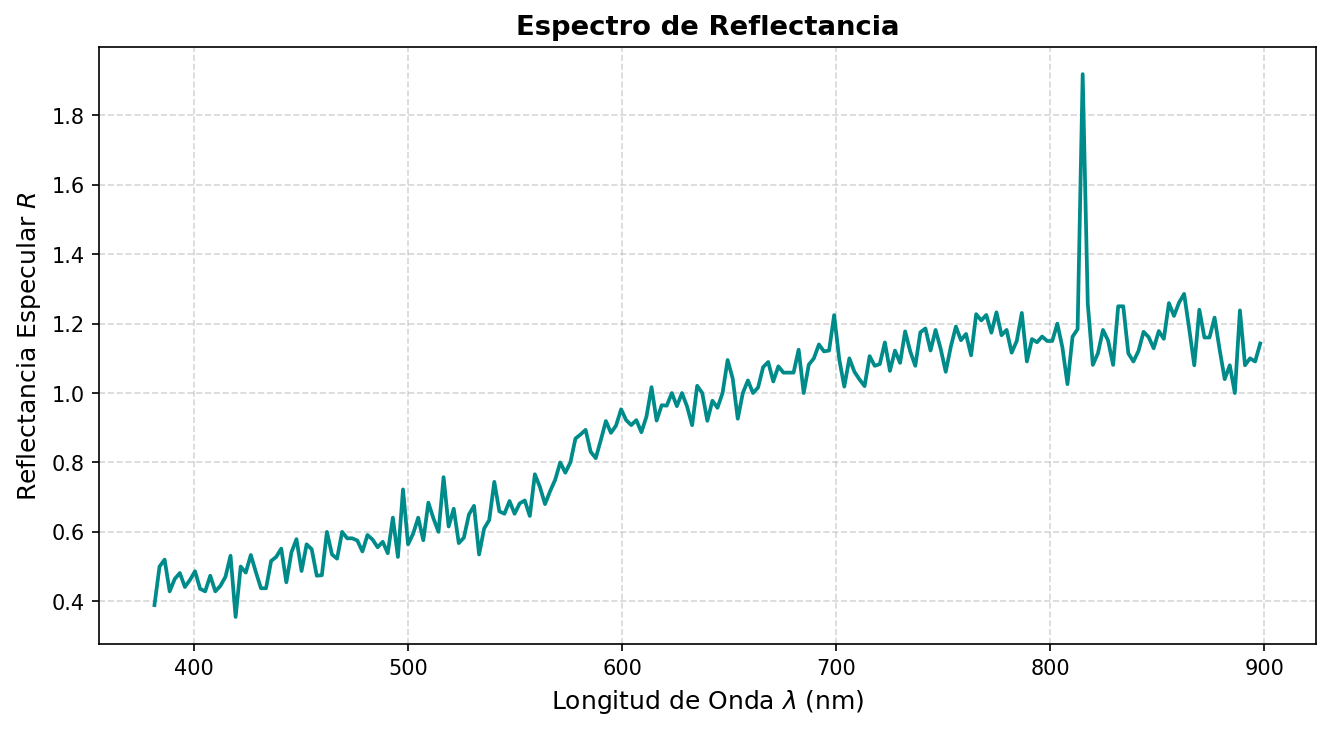

In [ ]:
# Mapeo lineal de los píxeles a longitudes de onda según la calibración del equipo
longitudes_onda = np.linspace(320, 1000, len(referencia))

# Aplicamos la ecuación de reflectancia
denominador = referencia - ruido

# Filtramos zonas donde la lámpara no tiene potencia para evitar división por cero (ruido numérico)
mascara_senal_util = denominador > 5

reflectancia = np.zeros_like(pelicula, dtype=float)
# Cálculo de reflectancia pura
reflectancia[mascara_senal_util] = (pelicula[mascara_senal_util] - ruido[mascara_senal_util]) / denominador[mascara_senal_util]

# Definimos la zona del espectro visible e IR cercano donde los datos son confiables
rango_visible = (longitudes_onda >= 380) & (longitudes_onda <= 900)

# Gráfica 2: Reflectancia Calibrada lista para el artículo
plt.figure(figsize=(9, 5))
plt.plot(longitudes_onda[rango_visible], reflectancia[rango_visible], color='darkcyan', linewidth=1.8)
plt.title('Espectro de Reflectancia', fontweight='bold')
plt.xlabel(r'Longitud de Onda $\lambda$ (nm)')
plt.ylabel('Reflectancia Especular $R$')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 3. Cálculo del Coeficiente de Atenuación ($\alpha$)

Para obtener el coeficiente de atenuación, asumimos un modelo óptico básico donde la película es débilmente absorbente y las pérdidas por esparcimiento (scattering) son mínimas. Por conservación de energía, la transmitancia se aproxima como $T \approx 1 - R$.

Aplicando la ley de Beer-Lambert, el coeficiente de atenuación $\alpha(\lambda)$ en función del espesor de la película ($d$) es:

$$\alpha(\lambda) \approx -\frac{1}{d} \ln(1 - R(\lambda))$$

**Restricción importante:** Esta aproximación matemática colapsa si $R \geq 1$ (lo cual sucede en nuestros datos en la zona del infrarrojo debido a efectos de interferencia en la película delgada o variaciones en la referencia). Por tanto, el código evalúa $\alpha$ únicamente en la región de 380 nm a 610 nm, que es la zona donde la física del modelo se mantiene coherente.

In [ ]:
# 1. LISTAS NATIVAS DE PYTHON
wavelength_list = [
    0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39,
    0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49,
    0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59,
    0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69,
    0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79,
    0.8, 0.81, 0.82, 0.83
]

R_list = [
    0.3530393620467649, 0.3720225686085378, 0.3853660368784829, 0.39762116161785704,
    0.4114133912643274, 0.42579130700667656, 0.44135251838430245, 0.45846910591226087,
    0.47475858706727003, 0.4904168635881989, 0.5069435148439017, 0.5233539887664383,
    0.539499227642153, 0.5550817662195534, 0.5691695478217582, 0.5815865817964907,
    0.5925678563148888, 0.6019743199592487, 0.6097425746286771, 0.6160155766871362,
    0.6217056594054929, 0.6264667010161048, 0.6317912380035786, 0.6390292148704457,
    0.651002357967688, 0.6747054593735344, 0.7207646144986721, 0.7942160480267394,
    0.869039154793009, 0.9188408017823908, 0.9446839513184572, 0.9568979839009122,
    0.9639846165040962, 0.968119633552246, 0.9707746397681446, 0.9730581736848871,
    0.9747860604582559, 0.9759929563377063, 0.9773539648486724, 0.9782022536459714,
    0.9791811103542714, 0.979958772615429, 0.980780399052294, 0.9815269890393921,
    0.9821973348638277, 0.9827626309721813, 0.983250649519775, 0.9838159926721575,
    0.9840217159516893, 0.9848465304251189, 0.9847994533477122, 0.9851891066957029,
    0.9857760675437872, 0.9857703274028389
]

# 2. ARRAYS DE NUMPY (Recomendado para ciencia de datos/gráficas)
wavelength_arr = np.array(wavelength_list)
R_arr = np.array(R_list)

In [ ]:
len(wavelength_arr), len(R_arr)

(54, 54)

<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_7930/2413469819.py:47: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Coeficiente de Atenuación del Cobre ($\lambda \leq 600$ nm)', fontsize=14, fontweight='bold', pad=15)


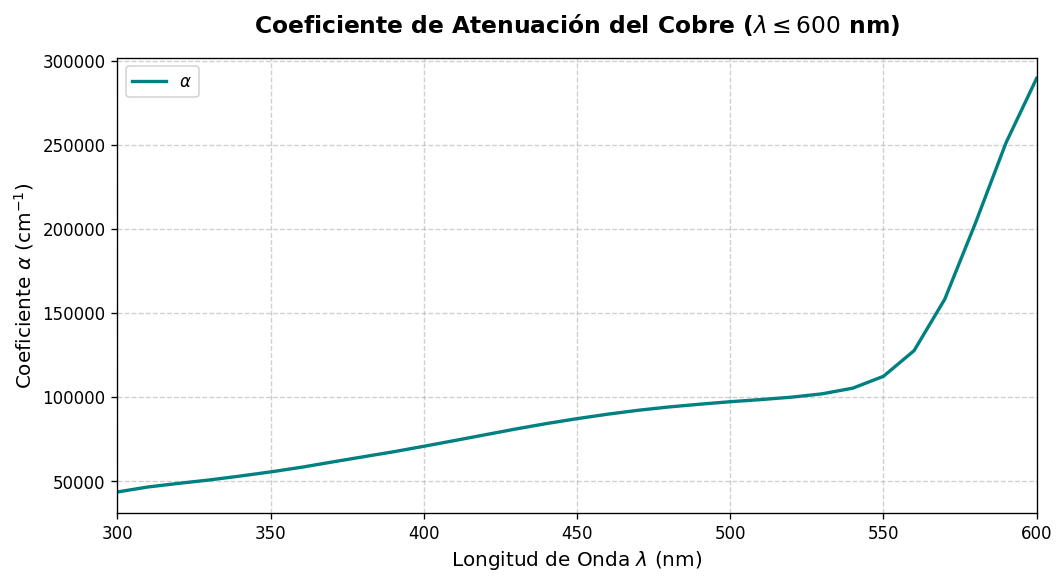

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar los datos de longitud de onda (en micrometros) y Reflectancia (R)
wavelength_um = np.array([
    0.3,  0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39,
    0.4,  0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49,
    0.5,  0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59,
    0.6,  0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69,
    0.7,  0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79,
    0.8,  0.81, 0.82, 0.83
])

R = np.array([
    0.3530393620467649,  0.3720225686085378,  0.3853660368784829,  0.39762116161785704,
    0.4114133912643274,  0.42579130700667656, 0.44135251838430245, 0.45846910591226087,
    0.47475858706727003, 0.4904168635881989,  0.5069435148439017,  0.5233539887664383,
    0.539499227642153,   0.5550817662195534,  0.5691695478217582,  0.5815865817964907,
    0.5925678563148888,  0.6019743199592487,  0.6097425746286771,  0.6160155766871362,
    0.6217056594054929,  0.6264667010161048,  0.6317912380035786,  0.6390292148704457,
    0.651002357967688,   0.6747054593735344,  0.7207646144986721,  0.7942160480267394,
    0.869039154793009,   0.9188408017823908,  0.9446839513184572,  0.9568979839009122,
    0.9639846165040962,  0.968119633552246,   0.9707746397681446,  0.9730581736848871,
    0.9747860604582559,  0.9759929563377063,  0.9773539648486724,  0.9782022536459714,
    0.9791811103542714,  0.979958772615429,   0.980780399052294,   0.9815269890393921,
    0.9821973348638277,  0.9827626309721813,  0.983250649519775,   0.9838159926721575,
    0.9840217159516893,  0.9848465304251189,  0.9847994533477122,  0.9851891066957029,
    0.9857760675437872,  0.9857703274028389
])

# 2. Definir parámetros físicos y conversión de unidades
d_cm = 100e-7
wavelength_nm = wavelength_um * 1000

# 3. Calcular el coeficiente de atenuacion (alpha) usando absortancia (1 - R)
alpha = -np.log(1 - R) / d_cm

# 4. FILTRO: Seleccionar solo longitudes de onda menores o iguales a 600 nm
mask = wavelength_nm <= 600
wavelength_plot = wavelength_nm[mask]
alpha_plot = alpha[mask]

# 5. Configurar y generar la gráfica
plt.figure(figsize=(9, 5), dpi=120)
plt.plot(wavelength_plot, alpha_plot, color='#008080', linewidth=2, label=r'$\alpha$ ')

plt.title('Coeficiente de Atenuación del Cobre ($\lambda \leq 600$ nm)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(r'Longitud de Onda $\lambda$ (nm)')
plt.ylabel(r'Coeficiente $\alpha$ ($\text{cm}^{-1}$)')
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar los límites del eje X estrictamente hasta 600 nm
plt.xlim(min(wavelength_plot), 600)

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

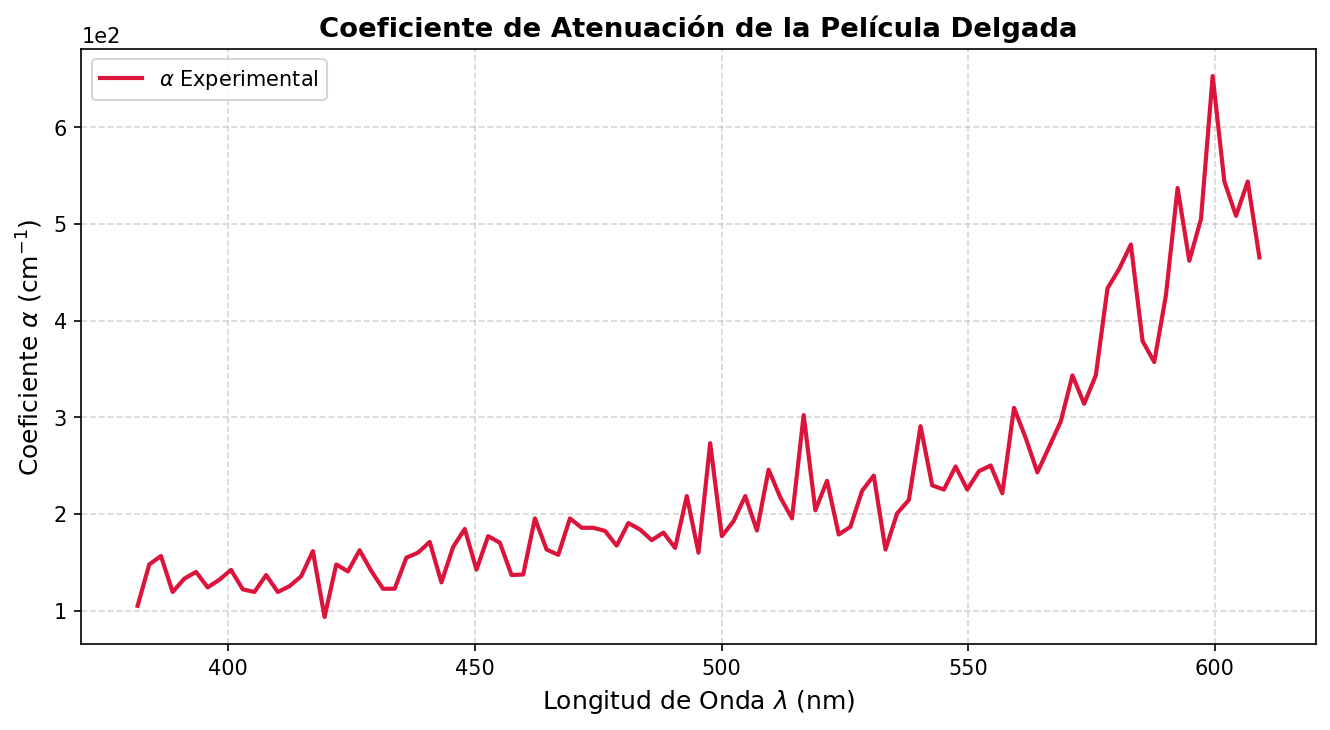

Los datos finales se exportaron en 'resultados_espectroscopia_sofia.txt'.


In [ ]:
# --- ¡OJO! CAMBIAR ESTE DATO ANTES DE CORRER ---
d_nm = 46884  # Espesor de la película en nanómetros (Reemplazar con dato real)
# -----------------------------------------------

d_cm = d_nm * 1e-7  # Pasamos el espesor a cm para que las unidades de alfa sean cm^-1

# Recortamos a la zona donde R < 1 estrictamente para que el logaritmo natural exista
zona_alfa = (longitudes_onda >= 380) & (longitudes_onda <= 610)
wav_alfa = longitudes_onda[zona_alfa]
R_alfa = reflectancia[zona_alfa]

# Estimamos transmitancia
T_estimada = 1.0 - R_alfa
# Filtro de seguridad numérico para evitar log(0) o valores negativos residuales
T_estimada[T_estimada <= 0] = 1e-5

# Cálculo final de alfa (cm^-1)
alfa_cm = - (1.0 / d_cm) * np.log(T_estimada)

# Gráfica 3: Coeficiente de Atenuación
plt.figure(figsize=(9, 5))
plt.plot(wav_alfa, alfa_cm, color='crimson', linewidth=2.0, label=r'$\alpha$ Experimental')
plt.title('Coeficiente de Atenuación de la Película Delgada', fontweight='bold')
plt.xlabel(r'Longitud de Onda $\lambda$ (nm)')
plt.ylabel(r'Coeficiente $\alpha$ ($\text{cm}^{-1}$)')
plt.grid(True, linestyle='--', alpha=0.5)

# Opcional: Formateo científico del eje Y
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Exportamos los datos limpios por si los necesitas meter directo a PGFPlots/TiKZ en Overleaf
datos_salida = np.column_stack((wav_alfa, R_alfa, alfa_cm))
np.savetxt('resultados_espectroscopia_sofia.txt', datos_salida,
           header='Wavelength_nm Reflectance Alpha_cm-1', fmt='%.4e')
print("Los datos finales se exportaron en 'resultados_espectroscopia_sofia.txt'.")

### 4. Análisis Físico: Comportamiento Óptico del Cobre (Cu)

Dado que la película evaporada en la cámara de vacío es de cobre (Cu), las curvas obtenidas reflejan de manera precisa la firma óptica de este metal. El cobre es conocido por su característico color rojizo/anaranjado, el cual es consecuencia directa de su estructura de bandas electrónicas:

1. **Reflectancia:** En la región de longitudes de onda cortas (400 nm - 500 nm, correspondientes al azul y verde), el cobre absorbe fuertemente la luz debido a las transiciones interbanda de los electrones. Esto se evidencia en nuestra gráfica de reflectancia, donde los valores inician bajos (cerca de 0.4). A partir de los ~550 nm, la reflectancia se dispara, estabilizándose en valores muy altos en el rojo y el infrarrojo cercano (> 600 nm).
2. **Coeficiente de Atenuación ($\alpha$):** La gráfica de atenuación confirma este fenómeno. Observamos una mayor atenuación hacia el ultravioleta y el espectro visible de alta energía, la cual va disminuyendo drásticamente a medida que nos acercamos a la región donde el material se vuelve altamente reflectante.

### 5. Consideraciones del Modelo y el Sustrato

Para el cálculo del coeficiente de atenuación, se asumió la aproximación $T \approx 1 - R$. Es importante notar para la discusión de los resultados que este modelo simplificado tiene ciertas limitaciones experimentales:
* **El Sustrato de Vidrio:** La película se creció sobre vidrio. En la realidad, la luz que logra penetrar el cobre se encuentra con la interfaz vidrio-aire en la parte posterior, la cual tiene su propia reflectancia (aproximadamente un 4%). Nuestro cálculo asume que esta reflexión trasera es despreciable en comparación con la alta absorción y reflexión del metal.
* **Esparcimiento (Scattering):** Se asume que la película es lo suficientemente lisa y uniforme como para que las pérdidas por esparcimiento difuso sean nulas.
* **Saturación:** La zona del espectro donde $R \geq 1$ (infrarrojo) fue excluida del cálculo de $\alpha$, ya que físicamente indica que el estándar de referencia empleado reflejó menos luz que nuestra película en esa banda específica, haciendo inviable la aproximación matemática por el logaritmo natural de un número negativo.